# ColliderML SSL representation evaluation

Compare the baseline and nine augmentation ablations using only the saved linear-probe outputs. This notebook does **not** reload GravNet or rerun embedding extraction.

Expected layout: `classifier_output/<experiment>/{latents.npz,test_predictions.npz,history.csv,metrics.json}`. Figures are written to `evaluation_outputs/figures/`.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

RESULTS_DIR = Path("classifier_output")
OUTPUT_DIR = Path("evaluation_outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    "baseline", "no_rotation", "rotation_pi4",
    "no_energy_noise", "energy_noise_010",
    "no_xyz_noise", "xyz_noise_2", "energy_first",
    "rotate_then_shift", "shift_then_rotate",
]
CLASS_NAMES = ["ttbar", "ggf"]
CLASS_COLORS = ["#2878B5", "#E07B39"]
RANDOM_STATE = 53

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print(f"UMAP available: {HAS_UMAP}")

/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP available: True


## 1. Load all ten experiments

This is the single structural consistency check. All later cells reuse the loaded arrays.

In [2]:
results = {}
required_latent_keys = {"train_x", "train_y", "val_x", "val_y", "test_x", "test_y"}
required_prediction_keys = {"labels", "probabilities"}

for experiment in EXPERIMENTS:
    directory = RESULTS_DIR / experiment
    if not directory.is_dir():
        raise FileNotFoundError(f"Missing result directory: {directory}")

    with np.load(directory / "latents.npz") as archive:
        if set(archive.files) != required_latent_keys:
            raise ValueError(f"Unexpected latent keys for {experiment}: {archive.files}")
        latents = {key: archive[key].copy() for key in archive.files}

    with np.load(directory / "test_predictions.npz") as archive:
        if set(archive.files) != required_prediction_keys:
            raise ValueError(f"Unexpected prediction keys for {experiment}: {archive.files}")
        predictions = {key: archive[key].copy() for key in archive.files}

    metrics = json.loads((directory / "metrics.json").read_text())
    history = pd.read_csv(directory / "history.csv")
    results[experiment] = {
        "latents": latents, "predictions": predictions,
        "metrics": metrics, "history": history,
    }

reference_labels = results["baseline"]["predictions"]["labels"]
same_test_labels = all(
    np.array_equal(reference_labels, results[e]["predictions"]["labels"])
    for e in EXPERIMENTS
)
if not same_test_labels:
    warnings.warn("Test-label ordering differs across experiments; metrics remain valid, but event-by-event comparisons are disabled.")

shape_rows = []
for experiment in EXPERIMENTS:
    z = results[experiment]["latents"]
    shape_rows.append({
        "experiment": experiment,
        "train": z["train_x"].shape,
        "validation": z["val_x"].shape,
        "test": z["test_x"].shape,
    })

print(f"Loaded {len(results)} experiments; identical test-label ordering: {same_test_labels}")
display(pd.DataFrame(shape_rows))

Loaded 10 experiments; identical test-label ordering: True


,experiment,train,validation,test
0,baseline,"(2400, 64)","(300, 64)","(300, 64)"
1,no_rotation,"(2400, 64)","(300, 64)","(300, 64)"
2,rotation_pi4,"(2400, 64)","(300, 64)","(300, 64)"
3,no_energy_noise,"(2400, 64)","(300, 64)","(300, 64)"
4,energy_noise_010,"(2400, 64)","(300, 64)","(300, 64)"
5,no_xyz_noise,"(2400, 64)","(300, 64)","(300, 64)"
6,xyz_noise_2,"(2400, 64)","(300, 64)","(300, 64)"
7,energy_first,"(2400, 64)","(300, 64)","(300, 64)"
8,rotate_then_shift,"(2400, 64)","(300, 64)","(300, 64)"
9,shift_then_rotate,"(2400, 64)","(300, 64)","(300, 64)"


## 2. Linear-probe metrics and baseline deltas

In [3]:
summary_rows = []
for experiment in EXPERIMENTS:
    metric = results[experiment]["metrics"]
    summary_rows.append({
        "experiment": experiment,
        "test_accuracy": metric["test_accuracy"],
        "test_roc_auc": metric["test_roc_auc"],
        "val_accuracy": metric["val_accuracy"],
        "test_loss": metric["test_loss"],
        "best_val_loss": metric["best_val_loss"],
        "best_epoch": metric["best_epoch"],
    })

summary = pd.DataFrame(summary_rows).set_index("experiment").loc[EXPERIMENTS]
summary["accuracy_delta_vs_baseline"] = summary["test_accuracy"] - summary.loc["baseline", "test_accuracy"]
summary["auc_delta_vs_baseline"] = summary["test_roc_auc"] - summary.loc["baseline", "test_roc_auc"]
display(summary.round(4))

,test_accuracy,test_roc_auc,val_accuracy,test_loss,best_val_loss,best_epoch,accuracy_delta_vs_baseline,auc_delta_vs_baseline
experiment,,,,,,,,
baseline,0.8167,0.9293,0.8767,0.3450,0.3543,100,0.0000,0.0000
no_rotation,0.8533,0.9400,0.8600,0.3269,0.3632,100,0.0367,0.0107
rotation_pi4,0.8367,0.9268,0.8667,0.3512,0.3471,100,0.0200,-0.0025
no_energy_noise,0.8833,0.9376,0.8667,0.3343,0.3277,100,0.0667,0.0083
energy_noise_010,0.8133,0.9347,0.8533,0.3452,0.3677,100,-0.0033,0.0054
no_xyz_noise,0.8433,0.9304,0.8600,0.3493,0.3588,100,0.0267,0.0011
xyz_noise_2,0.8333,0.9280,0.8600,0.3490,0.3659,100,0.0167,-0.0013
energy_first,0.8333,0.9292,0.8567,0.3427,0.3587,100,0.0167,-0.0001
rotate_then_shift,0.8267,0.9280,0.8600,0.3453,0.3735,100,0.0100,-0.0013


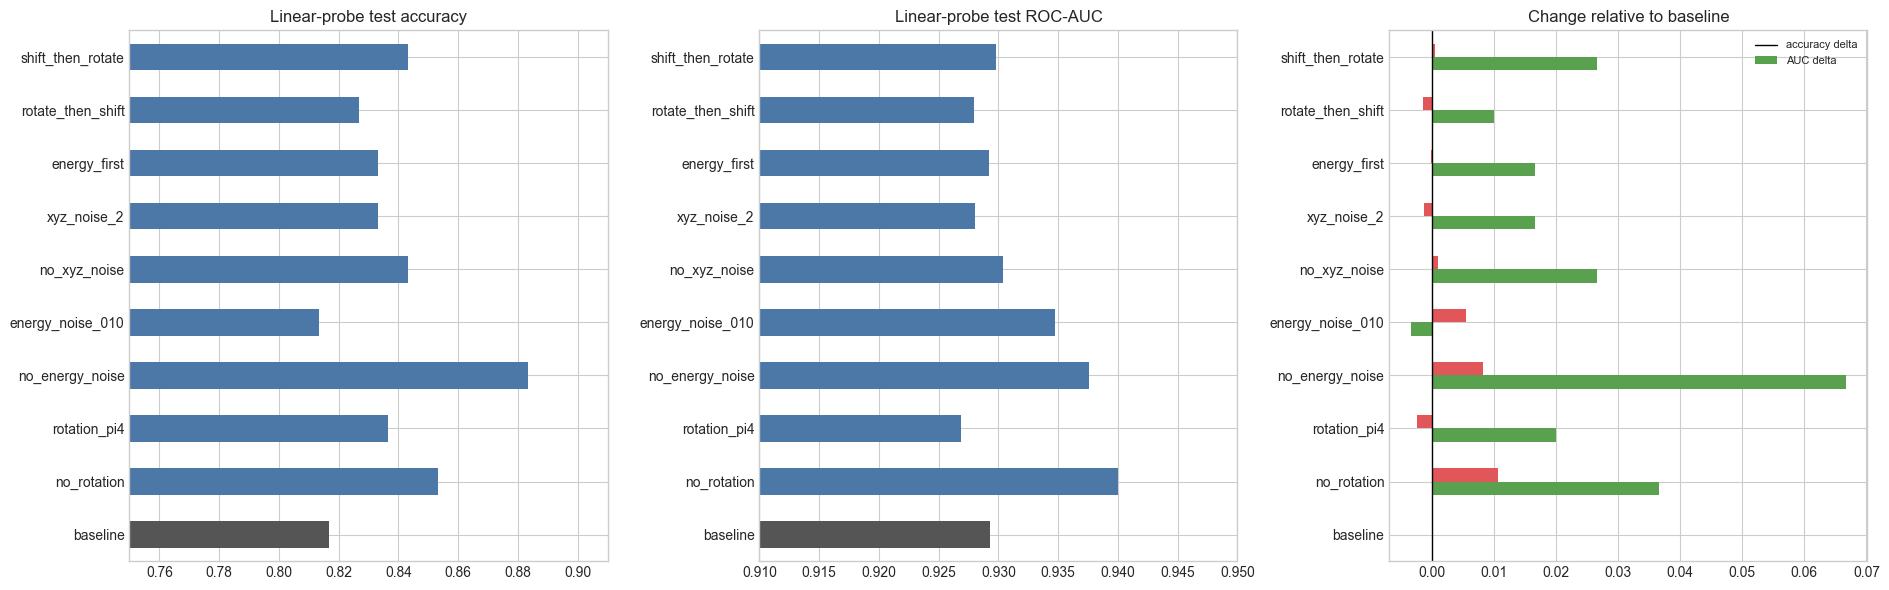

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
colors = ["#555555" if e == "baseline" else "#4C78A8" for e in EXPERIMENTS]

summary["test_accuracy"].plot.barh(ax=axes[0], color=colors)
axes[0].set_title("Linear-probe test accuracy")
axes[0].set_xlim(0.75, 0.91)

summary["test_roc_auc"].plot.barh(ax=axes[1], color=colors)
axes[1].set_title("Linear-probe test ROC-AUC")
axes[1].set_xlim(0.91, 0.95)

delta = summary[["accuracy_delta_vs_baseline", "auc_delta_vs_baseline"]]
delta.plot.barh(ax=axes[2], color=["#59A14F", "#E15759"])
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title("Change relative to baseline")
axes[2].legend(["accuracy delta", "AUC delta"], fontsize=8)

for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "linear_probe_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Linear-probe histories

These are classifier-training curves, not SSL pretraining curves.

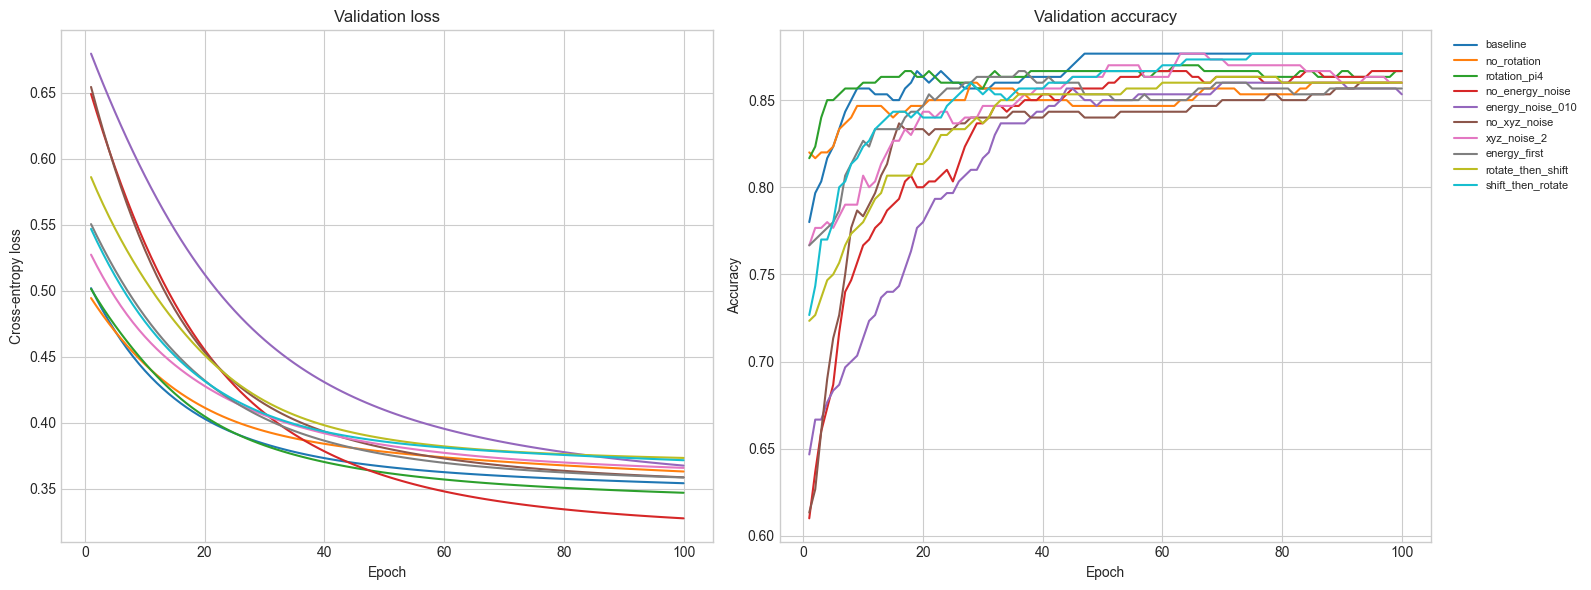

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for experiment in EXPERIMENTS:
    history = results[experiment]["history"]
    axes[0].plot(history["epoch"], history["val_loss"], label=experiment, linewidth=1.5)
    axes[1].plot(history["epoch"], history["val_accuracy"], label=experiment, linewidth=1.5)
axes[0].set(title="Validation loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[1].set(title="Validation accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "linear_probe_histories.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. ROC curves and confusion matrices

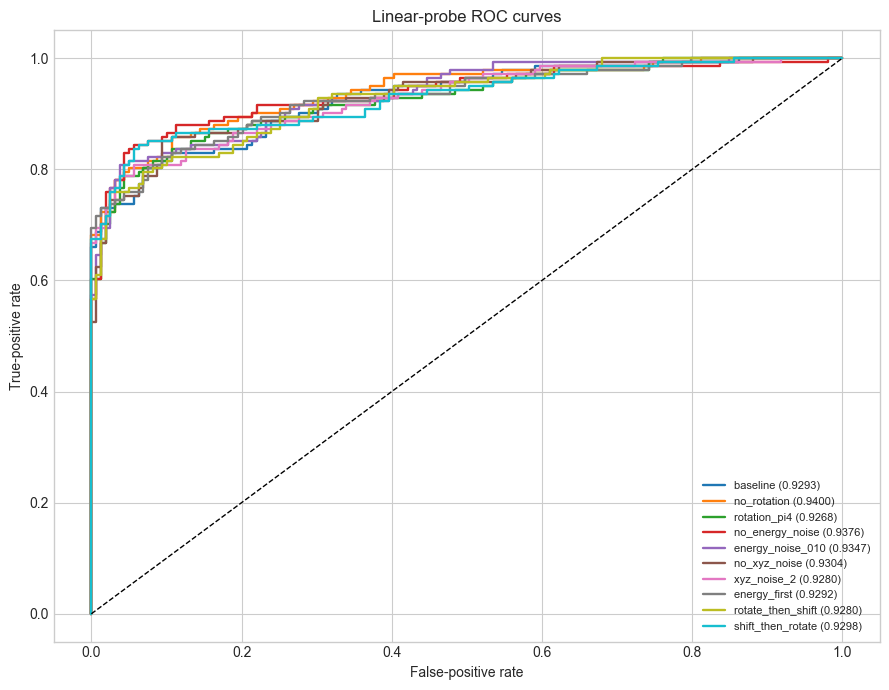

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
for experiment in EXPERIMENTS:
    prediction = results[experiment]["predictions"]
    labels = prediction["labels"]
    probabilities = prediction["probabilities"]
    fpr, tpr, _ = roc_curve(labels, probabilities)
    score = roc_auc_score(labels, probabilities)
    ax.plot(fpr, tpr, linewidth=1.7, label=f"{experiment} ({score:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title="Linear-probe ROC curves")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

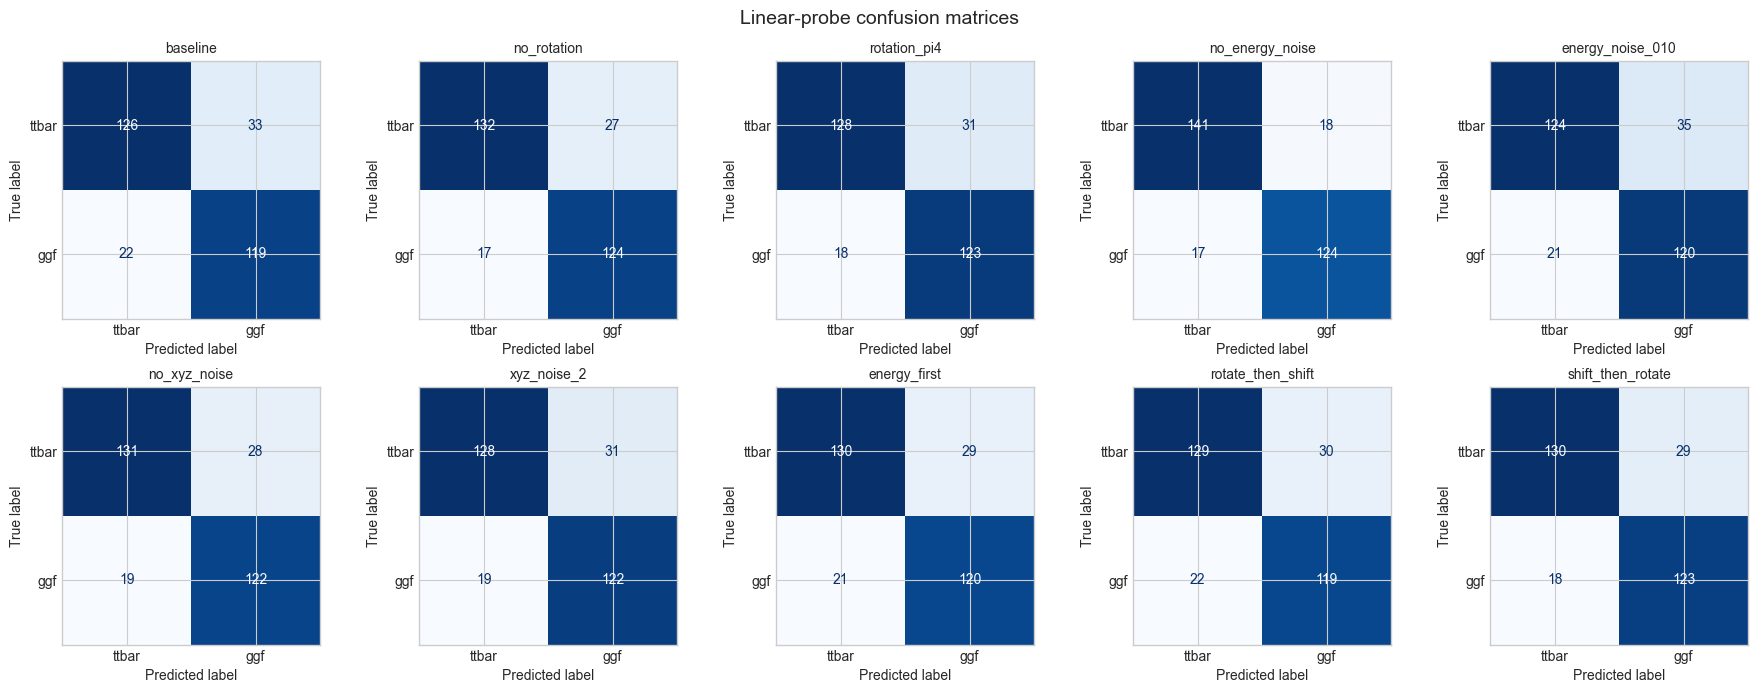

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, experiment in zip(axes.flat, EXPERIMENTS):
    prediction = results[experiment]["predictions"]
    labels = prediction["labels"]
    predicted = (prediction["probabilities"] >= 0.5).astype(int)
    matrix = confusion_matrix(labels, predicted, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d"
    )
    ax.set_title(experiment, fontsize=10)
fig.suptitle("Linear-probe confusion matrices", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Fixed kNN evaluation

One fixed configuration is used for every experiment: training-set standardization and distance-weighted `k=15`. There is no hyperparameter sweep or cross-validation.

,test_accuracy,test_roc_auc,val_accuracy,test_loss,best_val_loss,best_epoch,accuracy_delta_vs_baseline,auc_delta_vs_baseline,knn_test_accuracy,knn_delta_vs_baseline
experiment,,,,,,,,,,
baseline,0.8167,0.9293,0.8767,0.3450,0.3543,100,0.0000,0.0000,0.8500,0.0000
no_rotation,0.8533,0.9400,0.8600,0.3269,0.3632,100,0.0367,0.0107,0.8533,0.0033
rotation_pi4,0.8367,0.9268,0.8667,0.3512,0.3471,100,0.0200,-0.0025,0.8533,0.0033
no_energy_noise,0.8833,0.9376,0.8667,0.3343,0.3277,100,0.0667,0.0083,0.8733,0.0233
energy_noise_010,0.8133,0.9347,0.8533,0.3452,0.3677,100,-0.0033,0.0054,0.8400,-0.0100
no_xyz_noise,0.8433,0.9304,0.8600,0.3493,0.3588,100,0.0267,0.0011,0.8633,0.0133
xyz_noise_2,0.8333,0.9280,0.8600,0.3490,0.3659,100,0.0167,-0.0013,0.8433,-0.0067
energy_first,0.8333,0.9292,0.8567,0.3427,0.3587,100,0.0167,-0.0001,0.8767,0.0267
rotate_then_shift,0.8267,0.9280,0.8600,0.3453,0.3735,100,0.0100,-0.0013,0.8367,-0.0133


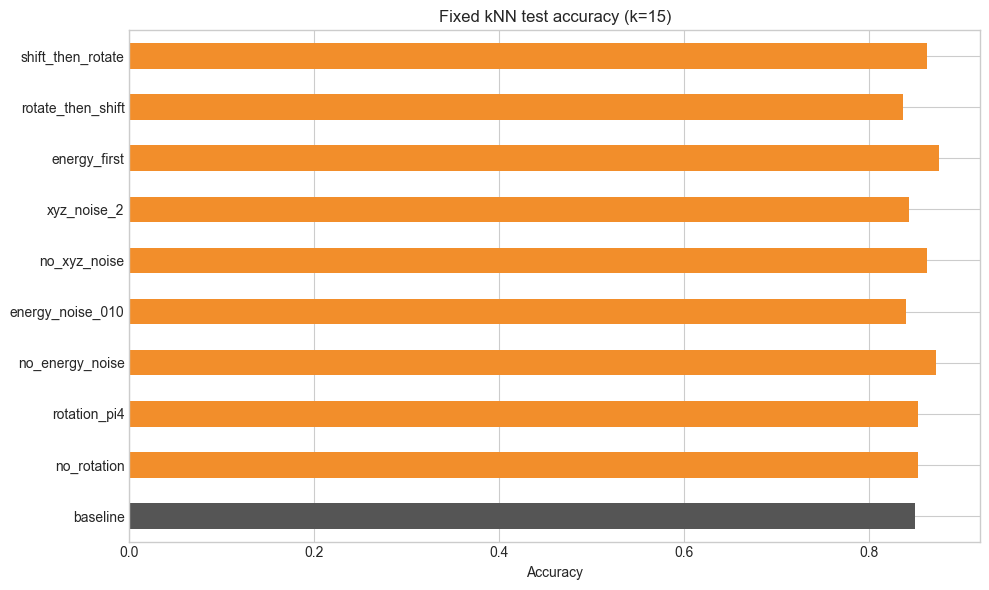

In [8]:
knn_scores = {}
for experiment in EXPERIMENTS:
    z = results[experiment]["latents"]
    scaler = StandardScaler().fit(z["train_x"])
    train_x = scaler.transform(z["train_x"])
    test_x = scaler.transform(z["test_x"])
    model = KNeighborsClassifier(n_neighbors=15, weights="distance")
    model.fit(train_x, z["train_y"])
    knn_scores[experiment] = accuracy_score(z["test_y"], model.predict(test_x))

summary["knn_test_accuracy"] = pd.Series(knn_scores)
summary["knn_delta_vs_baseline"] = summary["knn_test_accuracy"] - summary.loc["baseline", "knn_test_accuracy"]
summary.to_csv(OUTPUT_DIR / "evaluation_summary.csv")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
summary["knn_test_accuracy"].plot.barh(ax=ax, color=["#555555" if e == "baseline" else "#F28E2B" for e in EXPERIMENTS])
ax.set(title="Fixed kNN test accuracy (k=15)", xlabel="Accuracy", ylabel="")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "knn_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Latent-space collapse and dimensionality diagnostics

In [9]:
diagnostic_rows = []
standardized = {}

for experiment in EXPERIMENTS:
    z = results[experiment]["latents"]
    scaler = StandardScaler().fit(z["train_x"])
    train_scaled = scaler.transform(z["train_x"])
    test_scaled = scaler.transform(z["test_x"])
    standardized[experiment] = {"train_x": train_scaled, "test_x": test_scaled}

    raw_std = z["train_x"].std(axis=0)
    covariance = np.cov(train_scaled, rowvar=False)
    eigenvalues = np.clip(np.linalg.eigvalsh(covariance), 0, None)
    weights = eigenvalues / eigenvalues.sum()
    weights = weights[weights > 0]
    effective_rank = float(np.exp(-np.sum(weights * np.log(weights))))
    pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(train_scaled)

    diagnostic_rows.append({
        "experiment": experiment,
        "embedding_dim": z["train_x"].shape[1],
        "mean_dimension_std": raw_std.mean(),
        "minimum_dimension_std": raw_std.min(),
        "near_zero_dimensions": int((raw_std < 1e-6).sum()),
        "effective_rank": effective_rank,
        "pca_2d_explained_variance": pca.explained_variance_ratio_.sum(),
    })

diagnostics = pd.DataFrame(diagnostic_rows).set_index("experiment").loc[EXPERIMENTS]
diagnostics.to_csv(OUTPUT_DIR / "embedding_diagnostics.csv")
display(diagnostics.round(4))

,embedding_dim,mean_dimension_std,minimum_dimension_std,near_zero_dimensions,effective_rank,pca_2d_explained_variance
experiment,,,,,,
baseline,64,0.1490,0.0655,0,7.3975,0.5573
no_rotation,64,0.1418,0.0684,0,9.1709,0.4915
rotation_pi4,64,0.1517,0.0755,0,6.4015,0.6125
no_energy_noise,64,0.1623,0.0876,0,9.5980,0.5025
energy_noise_010,64,0.1270,0.0644,0,8.1004,0.5413
no_xyz_noise,64,0.1557,0.0732,0,7.7335,0.5451
xyz_noise_2,64,0.1489,0.0712,0,8.3478,0.5191
energy_first,64,0.1422,0.0584,0,8.1076,0.5364
rotate_then_shift,64,0.1515,0.0830,0,7.8207,0.5352


## 7. PCA comparison

Each model is projected separately because latent coordinate systems are not shared across independently trained encoders.

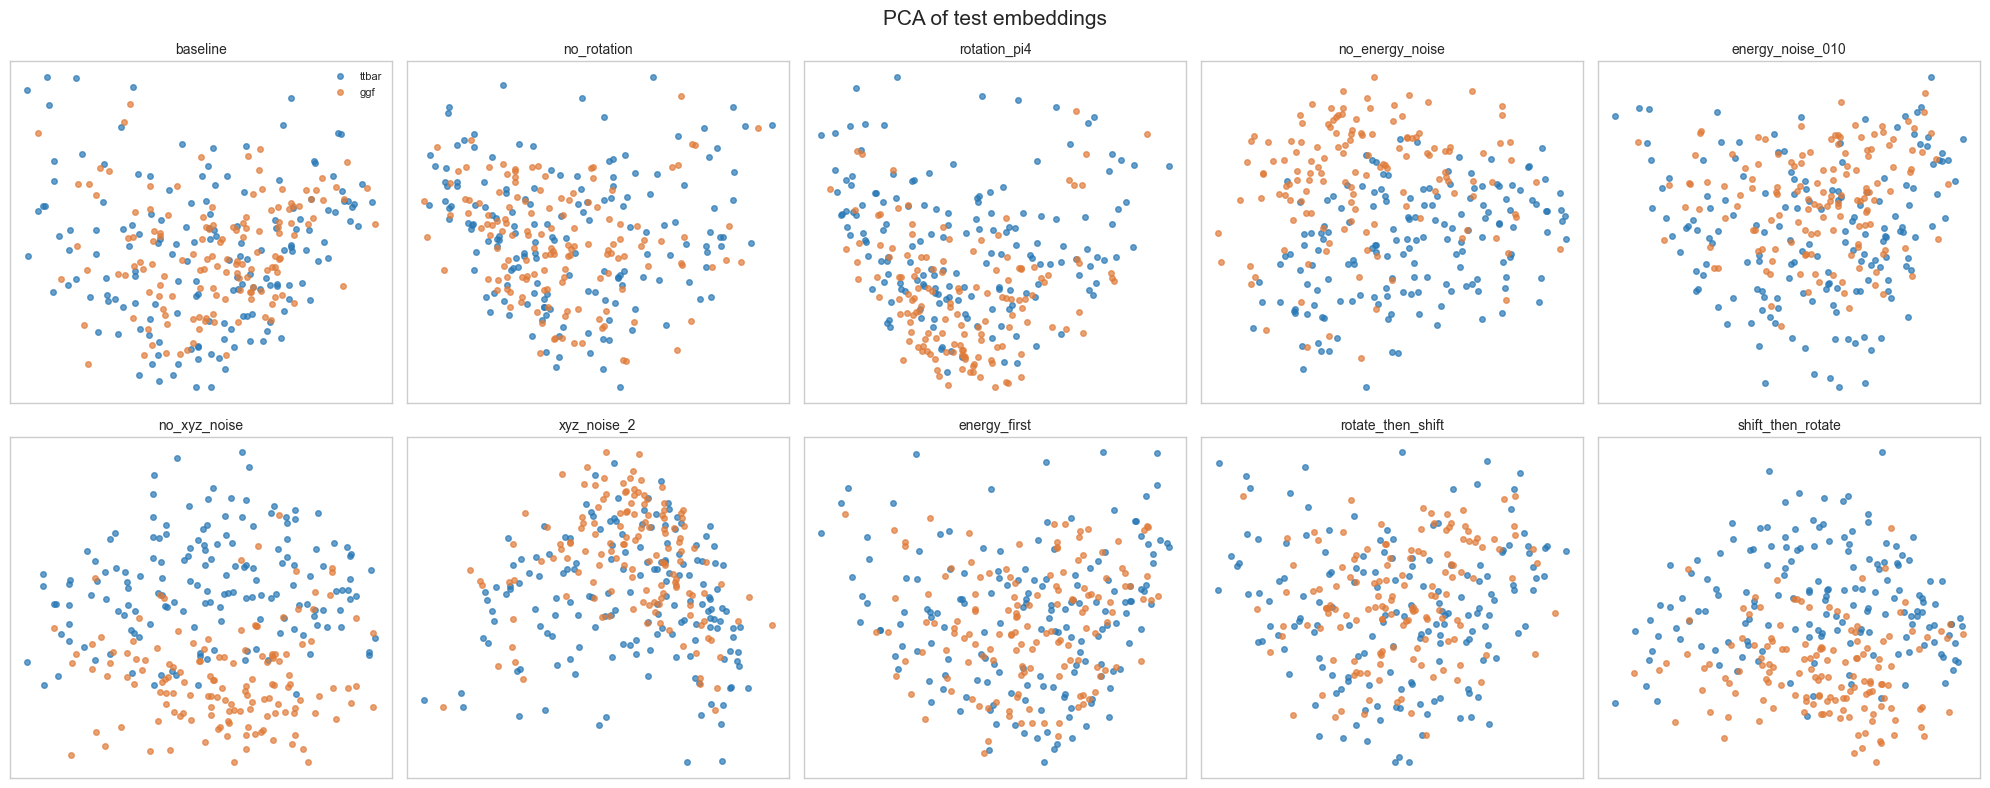

In [10]:
def scatter_projection_grid(projected, filename, title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, experiment in zip(axes.flat, EXPERIMENTS):
        points = projected[experiment]
        labels = results[experiment]["latents"]["test_y"]
        for class_id, (class_name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
            mask = labels == class_id
            ax.scatter(points[mask, 0], points[mask, 1], s=16, alpha=0.7, color=color, label=class_name)
        ax.set_title(experiment, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, 0].legend(loc="best", fontsize=8)
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

pca_projected = {}
for experiment in EXPERIMENTS:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(standardized[experiment]["train_x"])
    pca_projected[experiment] = pca.transform(standardized[experiment]["test_x"])
scatter_projection_grid(pca_projected, "pca_comparison.png", "PCA of test embeddings")

## 8. t-SNE comparison

The fixed settings are applied once to the test embeddings from each experiment.

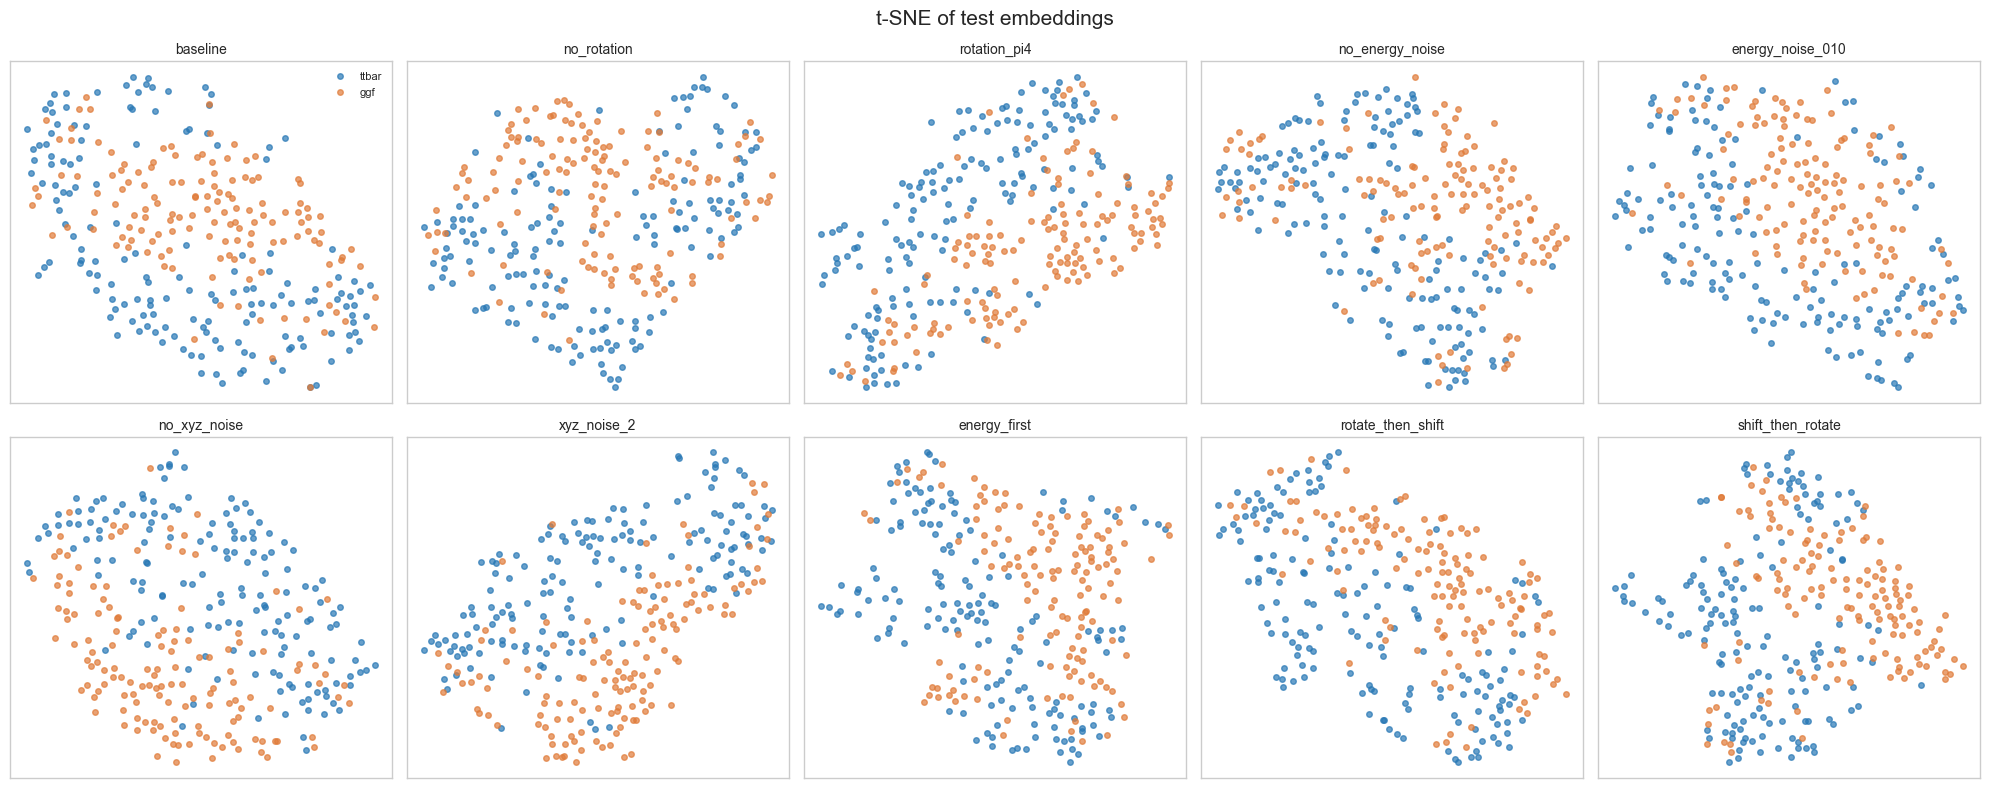

In [11]:
tsne_projected = {}
for experiment in EXPERIMENTS:
    tsne = TSNE(
        n_components=2, perplexity=30, learning_rate="auto",
        init="pca", random_state=RANDOM_STATE,
    )
    tsne_projected[experiment] = tsne.fit_transform(standardized[experiment]["test_x"])
scatter_projection_grid(tsne_projected, "tsne_comparison.png", "t-SNE of test embeddings")

## 9. UMAP comparison


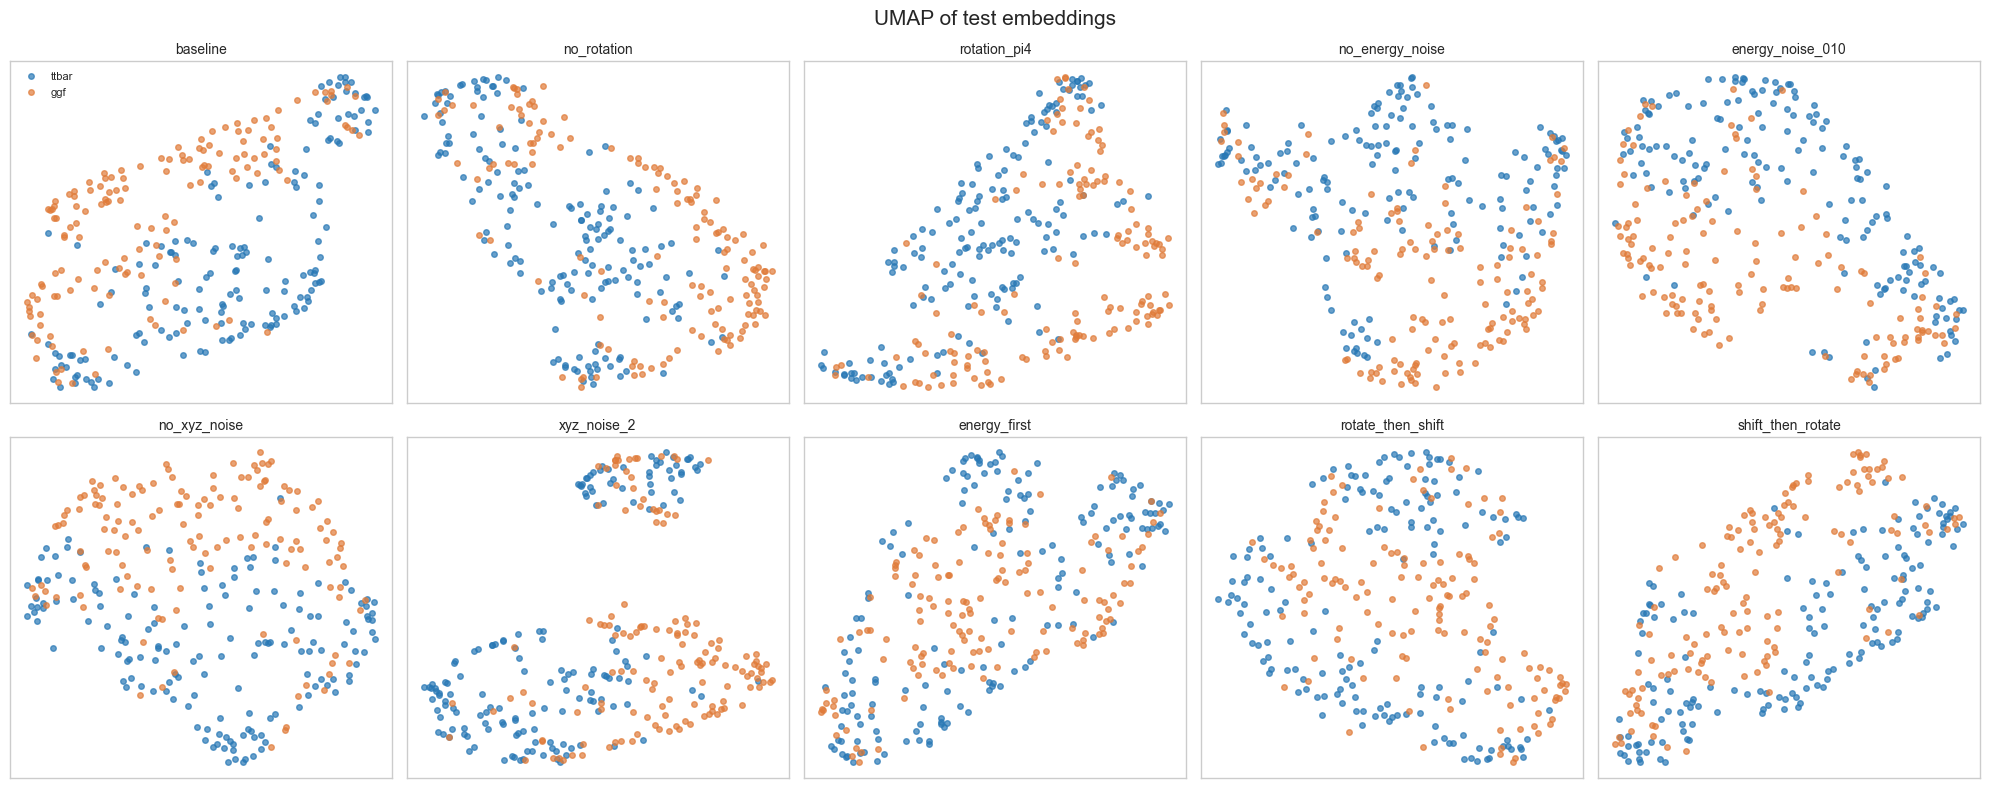

In [12]:
if HAS_UMAP:
    umap_projected = {}
    for experiment in EXPERIMENTS:
        reducer = umap.UMAP(
            n_components=2, n_neighbors=15, min_dist=0.1,
            metric="euclidean", random_state=RANDOM_STATE, n_jobs=1,
        )
        umap_projected[experiment] = reducer.fit_transform(standardized[experiment]["test_x"])
    scatter_projection_grid(umap_projected, "umap_comparison.png", "UMAP of test embeddings")
else:
    print("UMAP was skipped because umap-learn is not installed.")

## 10. Compact result summary

In [13]:
best_accuracy = summary["test_accuracy"].idxmax()
best_auc = summary["test_roc_auc"].idxmax()
best_knn = summary["knn_test_accuracy"].idxmax()
print(f"Best linear-probe accuracy: {best_accuracy} ({summary.loc[best_accuracy, 'test_accuracy']:.4f})")
print(f"Best linear-probe ROC-AUC:  {best_auc} ({summary.loc[best_auc, 'test_roc_auc']:.4f})")
print(f"Best fixed-kNN accuracy:     {best_knn} ({summary.loc[best_knn, 'knn_test_accuracy']:.4f})")
print(f"Saved tables to: {OUTPUT_DIR.resolve()}")
print(f"Saved figures to: {FIGURES_DIR.resolve()}")

Best linear-probe accuracy: no_energy_noise (0.8833)
Best linear-probe ROC-AUC:  no_rotation (0.9400)
Best fixed-kNN accuracy:     energy_first (0.8767)
Saved tables to: /Users/clintli/Desktop/hep_ssl_KunheLi/hep-ssl/chtc/notebook/classifier/evaluation_outputs
Saved figures to: /Users/clintli/Desktop/hep_ssl_KunheLi/hep-ssl/chtc/notebook/classifier/evaluation_outputs/figures
